## Single Neurone binary Classification with make_blobs dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_blobs(n_samples= 100, n_features=2, centers=2, random_state=0)
y = y.reshape(y.shape[0], 1)
y.shape

(100, 1)

In [3]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

def model(X, W, b):
    
    Z = X.dot(W) + b
    A = 1 /(1 + np.exp(-Z))
    
    return A

def log_loss(A, y):
    epsilon = 1e-15 # pour éviter de déterminer le log en 0
    return -1/len(y)*np.sum(y * np.log(A + epsilon) + (1 - y)*np.log(1-A + epsilon))

def gradients(A, X, y):
    
    dW = 1/len(y) * np.dot(X.T, A-y)
    db = 1/len(y) * np.sum(A - y)
    
    return (dW,db)

def update(dW, db, W, b, lr):
    
    W = W - lr * dW
    b = b - lr * db
    
    return (W, b)
def predict(X, W, b):
    
    A = model(X, W, b)
    
    #print('proba:', A)
    
    return A >= 0.5

In [4]:
def nn(X, y, lr = 0.1, n_iter = 100):
    
    #init
    W, b = initialisation(X)
    
    Loss = []
    
    for i in range(n_iter):
        A = model(X, W, b)
        loss = log_loss(A, y)
        Loss.append(loss)
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, lr)
        
    y_pred = predict(X, W, b)
    
    print(accuracy_score(y, y_pred))
    
    plt.plot(Loss)
    plt.show()
    
    return W, b

0.87


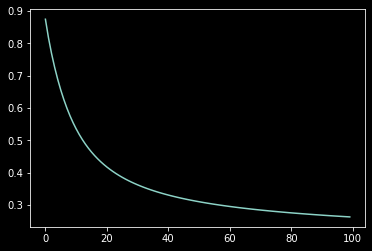

In [5]:
W, b = nn(X, y)

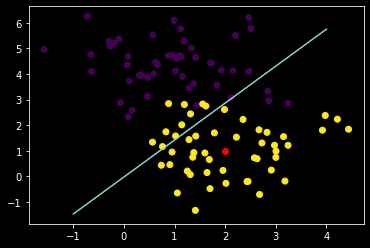

In [6]:
new_plant = np.array([2, 1])
plt.scatter(X[:,0], X[:, 1], c = y)
plt.scatter(new_plant[0], new_plant[1], c='r')
x0 = np.linspace(-1, 4, 100)
x1 = (-W[0]*x0 - b)/W[1]
plt.plot(x0, x1)
plt.show()

In [7]:
predict(new_plant, W, b)

array([ True])